# 04 — Model Interpretation and Chemical Insights

## Overview

Notebook 03 established that nonlinear tree-based models substantially outperformed the reduced linear QSAR model in predicting Nav1.7 inhibitory potency. XGBoost achieved the strongest overall held-out performance (**R² = 0.549, RMSE = 0.708 pIC₅₀ units**), although Random Forest produced comparable predictive performance.

This notebook shifts the focus from **predictive performance to chemical interpretation and discovery**.

The primary objective is to investigate what relationships the validated XGBoost model learned between molecular properties and Nav1.7 inhibitory potency. Rather than treating the model solely as a prediction tool, model-explanation methods are used to identify important molecular descriptors and characterize nonlinear, threshold-dependent, and potentially interacting relationships that may not be apparent from pairwise correlations or linear QSAR analysis.

The seven chemistry-informed descriptors examined are:

- Molecular Weight (MW)
- LogP
- Topological Polar Surface Area (TPSA)
- Hydrogen-Bond Donors (HBD)
- Rotatable Bonds
- Ring Count
- Fraction Csp³

SHAP (SHapley Additive exPlanations) is used as the primary model-interpretation framework. SHAP values quantify how individual descriptor values shift XGBoost predictions relative to the model's baseline prediction, allowing both the magnitude and direction of descriptor effects to be investigated.

Because the primary goal is **chemical relationship discovery across the available Nav1.7 chemical space**, the main SHAP analyses are performed across the complete **6,738-compound modeling dataset**. This provides greater coverage of descriptor values and improves the ability to examine nonlinear trends, transitions, and potential descriptor interactions.

The XGBoost model itself remains trained exclusively on the original **5,390-compound training set**. The **1,348 held-out test compounds are not used for model fitting** and retain their role in independent model validation. SHAP patterns observed across the full dataset are additionally compared with those obtained from the held-out test set to assess whether the principal interpretation patterns persist in compounds excluded from model training.

The interpretation workflow addresses four related questions:

1. **Which molecular descriptors contribute most strongly to XGBoost predictions of Nav1.7 inhibitory potency?**
2. **How does each important descriptor influence predicted pIC₅₀ across its observed chemical range?**
3. **Are important descriptor effects nonlinear, threshold-dependent, or influenced by interactions with other molecular properties?**
4. **How do the relationships identified by XGBoost compare with the correlations, linear QSAR coefficients, and Random Forest feature-importance patterns observed in earlier analyses?**

Particular attention is given to descriptors whose nonlinear importance differs from their simple linear association with potency. **Fraction Csp³** is especially notable because its weak pairwise relationship with pIC₅₀ contrasts with its substantial importance in the Random Forest model, suggesting that its predictive contribution may depend on nonlinear effects or interactions with other molecular properties.

All SHAP-derived relationships are interpreted as **model-derived predictive associations rather than direct evidence of biological causality or molecular mechanism**. The seven descriptors provide broad physicochemical and structural summaries but do not explicitly encode detailed molecular connectivity, binding interactions, ionization states, stereochemistry, or protein-ligand interactions.

The goal of this notebook is therefore not to claim a complete mechanistic explanation of Nav1.7 inhibition, but to use the validated nonlinear model as a tool for identifying **chemically meaningful patterns and hypotheses that can guide deeper structure-activity analysis**.

## 1. Load and Verify Interpretation Dataset

The finalized modeling dataset exported from Notebook 03 is loaded to establish the data foundation for model interpretation.

The dataset contains **6,738 GOOD-quality compounds** with experimental pIC₅₀ values and the seven chemistry-informed molecular descriptors used consistently during model development:

- Molecular Weight (MW)
- LogP
- Topological Polar Surface Area (TPSA)
- Hydrogen-Bond Donors (HBD)
- Rotatable Bonds
- Ring Count
- Fraction Csp³

Compound identifiers and canonical SMILES are retained to connect descriptor-level model behavior with individual molecular structures when needed.

The original **training/test assignment from Notebook 03 is also preserved**. This maintains the same 5,390-compound training set and 1,348-compound held-out test set used during model validation and prevents the interpretation workflow from introducing a new data split.

Before reconstructing the XGBoost model, the imported dataset is verified for dataset dimensions, expected columns, missing values, and train/test counts. This ensures that Notebook 04 begins with the same finalized chemical feature space and experimental design established in Notebook 03.

In [6]:

# ============================================================
# GLOBAL PLOT COLOR SCHEME
# ============================================================

# Primary plotting colors
COLOR_PRIMARY = '#4C78A8'      # Main blue
COLOR_SECONDARY = '#72A0C1'    # Secondary/light blue
COLOR_DARK = '#304F5B'         # Dark slate
COLOR_TREND = '#555555'        # Regression/trend lines
COLOR_ERROR = '#222222'        # Error bars and outlines

# Potency progression: weak → very potent
POTENCY_COLORS = [
    '#B8C9D6',   # Weak
    '#8EABC0',   # Medium
    '#5F83A3',   # Potent
    '#304F5B'    # Very Potent
]

In [1]:
# ============================================================
# 1. Load and Verify Interpretation Dataset
# ============================================================

import pandas as pd
import io
from google.colab import files

# 1. Upload the interpretation dataset exported from Notebook 03
print("Upload: nav17_model_interpretation_data.csv")

uploaded = files.upload()

# 2. Identify the uploaded file
file_name = list(uploaded.keys())[0]

# 3. Load the dataset
interpretation_df = pd.read_csv(
    io.BytesIO(uploaded[file_name])
)

# 4. Basic dataset audit
print("\n--- Interpretation Dataset Audit ---")
print(f"Loaded file:        {file_name}")
print(f"Total compounds:    {len(interpretation_df):,}")
print(f"Number of columns:  {interpretation_df.shape[1]}")

print(
    f"Training compounds: "
    f"{(interpretation_df['DatasetSplit'] == 'Train').sum():,}"
)

print(
    f"Test compounds:     "
    f"{(interpretation_df['DatasetSplit'] == 'Test').sum():,}"
)

print("\nColumns:")
print(interpretation_df.columns.tolist())

print("\nMissing values:")
print(interpretation_df.isnull().sum())

# 5. Preview
display(interpretation_df.head())

Upload: nav17_model_interpretation_data.csv


Saving nav17_model_interpretation_data.csv to nav17_model_interpretation_data.csv

--- Interpretation Dataset Audit ---
Loaded file:        nav17_model_interpretation_data.csv
Total compounds:    6,738
Number of columns:  11
Training compounds: 5,390
Test compounds:     1,348

Columns:
['molecule_chembl_id', 'canonical_smiles', 'pIC50', 'MW', 'LogP', 'TPSA', 'HBD', 'RotatableBonds', 'RingCount', 'FractionCSP3', 'DatasetSplit']

Missing values:
molecule_chembl_id    0
canonical_smiles      0
pIC50                 0
MW                    0
LogP                  0
TPSA                  0
HBD                   0
RotatableBonds        0
RingCount             0
FractionCSP3          0
DatasetSplit          0
dtype: int64


,molecule_chembl_id,canonical_smiles,pIC50,MW,LogP,TPSA,HBD,RotatableBonds,RingCount,FractionCSP3,DatasetSplit
0,CHEMBL3904041,C#Cc1cccc(OC2CN(c3ncnc(Nc4cccc(C(=O)NC)c4)n3)C...,6.004365,400.164774,2.2237,92.27,2.0,6.0,4.0,0.181818,Train
1,CHEMBL3662199,C/C=C/c1cc(C(=O)NS(=O)(=O)N2CCC2)c(F)cc1OCC12C...,8.221849,462.198857,4.1343,75.71,1.0,7.0,6.0,0.625000,Train
2,CHEMBL190461,C=C(C)[C@@H]1CCC(C)=C[C@H]1c1c(O)cc(CCCCC)cc1O,5.739929,314.224580,5.8465,40.46,2.0,6.0,2.0,0.523810,Train
3,CHEMBL3955581,C=C(C)c1ccccc1N1CCOc2cc(S(=O)(=O)Nc3nccs3)ccc21,5.616185,413.086783,4.5075,71.53,1.0,5.0,4.0,0.150000,Train
4,CHEMBL5805169,C=C(C)c1cn2c(NS(C)(=O)=O)nnc2cc1OCC12CC3CC(CC(...,7.291579,416.188212,3.7291,85.59,1.0,6.0,6.0,0.619048,Train


### Dataset Verification

The interpretation dataset was successfully loaded with **6,738 compounds and 11 columns**. The original Notebook 03 partition was preserved exactly, containing **5,390 training compounds** and **1,348 held-out test compounds**.

All seven finalized molecular descriptors, experimental pIC₅₀ values, compound identifiers, canonical SMILES, and dataset assignments were present with **no missing values**.

The verified dataset therefore reproduces the finalized modeling feature space and train/test structure established in Notebook 03 and can be used directly for model reconstruction and interpretation.

## 2. Reconstruct Final XGBoost Model

The final XGBoost QSAR model established in Notebook 03 is reconstructed using the preserved training/test assignments and the same seven chemistry-informed molecular descriptors.

The model is trained exclusively on the **5,390 compounds assigned to the training set**, while the **1,348 held-out test compounds remain excluded from model fitting**.

To reproduce the finalized modeling framework, the XGBoost hyperparameters are kept identical to those used in Notebook 03:

- **Number of trees (`n_estimators`) = 100**
- **Learning rate = 0.1**
- **Maximum tree depth = 6**
- **Random state = 42**

No additional feature selection, hyperparameter optimization, or model tuning is performed in this notebook.

Before beginning model interpretation, the reconstructed model is evaluated on the preserved held-out test set. Its R², RMSE, and MAE are compared with the final Notebook 03 results to verify that the same predictive model has been successfully reproduced.

Once model performance is confirmed, the reconstructed XGBoost model serves as the basis for the subsequent SHAP analyses.

In [4]:
# ============================================================
# 2. Reconstruct Final XGBoost Model
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from xgboost import XGBRegressor


# ------------------------------------------------------------
# 1. Define the exact seven descriptors used in Notebook 03
# ------------------------------------------------------------

reduced_descriptors = [
    'MW',
    'LogP',
    'TPSA',
    'HBD',
    'RotatableBonds',
    'RingCount',
    'FractionCSP3'
]


# ------------------------------------------------------------
# 2. Reconstruct X and y from the complete 6,738-row dataset
#    in the original saved row order
# ------------------------------------------------------------

X = interpretation_df[reduced_descriptors].copy()
y = interpretation_df['pIC50'].copy()

print("--- Complete Modeling Dataset ---")
print(f"Compounds:   {len(X):,}")
print(f"Descriptors: {X.shape[1]}")
print(f"Features:    {X.columns.tolist()}")


# ------------------------------------------------------------
# 3. Reproduce the EXACT Notebook 03 train/test split
# ------------------------------------------------------------

X_train_reduced, X_test_reduced, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n--- Reconstructed Train/Test Split ---")
print(f"Training compounds: {len(X_train_reduced):,}")
print(f"Test compounds:     {len(X_test_reduced):,}")


# ------------------------------------------------------------
# 4. Verify reconstructed membership against DatasetSplit
# ------------------------------------------------------------

saved_train_indices = set(
    interpretation_df.index[
        interpretation_df['DatasetSplit'] == 'Train'
    ]
)

saved_test_indices = set(
    interpretation_df.index[
        interpretation_df['DatasetSplit'] == 'Test'
    ]
)

reconstructed_train_indices = set(X_train_reduced.index)
reconstructed_test_indices = set(X_test_reduced.index)

train_match = (
    saved_train_indices == reconstructed_train_indices
)

test_match = (
    saved_test_indices == reconstructed_test_indices
)

print("\n--- Split Membership Verification ---")
print(f"Training membership matches saved split: {train_match}")
print(f"Test membership matches saved split:     {test_match}")

assert train_match, \
    "Reconstructed training membership does not match saved DatasetSplit."

assert test_match, \
    "Reconstructed test membership does not match saved DatasetSplit."


# ------------------------------------------------------------
# 5. Reconstruct exact Notebook 03 XGBoost model
# ------------------------------------------------------------

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

print("\nTraining reconstructed XGBoost model...")

xgb_model.fit(
    X_train_reduced,
    y_train
)

print("Training complete.")


# ------------------------------------------------------------
# 6. Generate predictions on the reconstructed held-out set
# ------------------------------------------------------------

xgb_test_pred = xgb_model.predict(
    X_test_reduced
)


# ------------------------------------------------------------
# 7. Calculate held-out metrics
# ------------------------------------------------------------

xgb_test_r2 = r2_score(
    y_test,
    xgb_test_pred
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_test_pred
    )
)

xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_pred
)


# ------------------------------------------------------------
# 8. Report results at higher precision
# ------------------------------------------------------------

print("\n--- Reconstructed XGBoost Held-Out Performance ---")
print(f"R²:   {xgb_test_r2:.6f}")
print(f"RMSE: {xgb_test_rmse:.6f} pIC₅₀ units")
print(f"MAE:  {xgb_test_mae:.6f} pIC₅₀ units")

--- Complete Modeling Dataset ---
Compounds:   6,738
Descriptors: 7
Features:    ['MW', 'LogP', 'TPSA', 'HBD', 'RotatableBonds', 'RingCount', 'FractionCSP3']

--- Reconstructed Train/Test Split ---
Training compounds: 5,390
Test compounds:     1,348

--- Split Membership Verification ---
Training membership matches saved split: True
Test membership matches saved split:     True

Training reconstructed XGBoost model...
Training complete.

--- Reconstructed XGBoost Held-Out Performance ---
R²:   0.549123
RMSE: 0.708427 pIC₅₀ units
MAE:  0.538847 pIC₅₀ units


### Model Reconstruction Verification

The finalized XGBoost model was successfully reconstructed using the original seven-descriptor feature space, 80/20 train-test split, and fixed model configuration established in Notebook 03.

Reapplying the original `train_test_split` procedure with `random_state=42` reproduced both the exact training/test membership and the original shuffled row ordering. The reconstructed model achieved a held-out **R² of 0.549**, **RMSE of 0.708 pIC₅₀ units**, and **MAE of 0.539 pIC₅₀ units**, reproducing the final performance reported in Notebook 03.

The model is therefore considered successfully reconstructed and is retained without further fitting or parameter modification for all subsequent interpretation analyses.

## 3. Global SHAP Analysis

SHAP (SHapley Additive exPlanations) analysis was used to examine how the seven molecular descriptors contribute to predictions generated by the validated XGBoost model.

For each compound, SHAP assigns a contribution value to every descriptor relative to the model's baseline prediction. A **positive SHAP value** indicates that a descriptor contributes toward a higher predicted pIC₅₀, whereas a **negative SHAP value** indicates a contribution toward a lower predicted pIC₅₀. The magnitude of the SHAP value reflects the strength of that descriptor's contribution to an individual prediction.

Because the primary objective of this notebook is **chemical interpretation and relationship discovery**, the main global SHAP analysis is performed across the complete **6,738-compound modeling dataset**. Using the full dataset provides broader coverage of the molecular descriptor space and allows model-derived chemical relationships to be examined across the complete collection of Nav1.7 inhibitors included in this study.

Global SHAP analysis evaluates two complementary aspects of model behavior:

- **Global descriptor importance**, measured using mean absolute SHAP values (mean |SHAP|), which quantify the average magnitude of each descriptor's contribution to model predictions.
- **Direction and distribution of descriptor effects**, examined using the SHAP summary plot, which relates low and high descriptor values to their positive or negative contributions to predicted pIC₅₀.

The resulting descriptor ranking provides a model-based measure of which physicochemical and structural properties most strongly influence XGBoost predictions. The distribution of SHAP values additionally reveals whether high or low values of a descriptor tend to increase or decrease predicted potency and whether its effects appear uniform or heterogeneous across chemical space.

Because **5,390 of the 6,738 compounds were used to train the XGBoost model**, full-dataset SHAP results are interpreted as descriptions of relationships learned by the model rather than as independent evidence of generalization. To assess the robustness of these interpretations, global SHAP importance is additionally calculated for the **1,348 held-out test compounds** and compared with the full-dataset descriptor ranking.

Agreement between the full-dataset and held-out SHAP patterns would indicate that the principal descriptor relationships learned by XGBoost are also expressed when the model is applied to compounds excluded from training.

Global SHAP importance is interpreted as **predictive association rather than biological causality**. These results establish the major descriptor-level patterns learned by XGBoost and provide the foundation for subsequent analyses of nonlinear relationships, descriptor-specific effects, and potential chemical interactions.

### 3.1 Global SHAP Feature Importance

Global feature importance was quantified using the mean absolute SHAP value for each molecular descriptor across the complete 6,738-compound dataset.

Mean |SHAP| measures the average magnitude of a descriptor's contribution to XGBoost predictions, regardless of whether that contribution increases or decreases predicted pIC₅₀. Descriptors with larger mean |SHAP| values therefore exert a greater overall influence on model predictions.

This analysis provides a model-based ranking of the seven molecular descriptors and identifies the properties that should receive the greatest attention in subsequent chemical interpretation. Because mean |SHAP| measures contribution magnitude rather than direction, the direction and distribution of these effects are examined separately in the SHAP summary and descriptor-dependence analyses.

--- Global SHAP Analysis Dataset ---
Compounds:   6,738
Descriptors: 7
Features:    ['MW', 'LogP', 'TPSA', 'HBD', 'RotatableBonds', 'RingCount', 'FractionCSP3']

Calculating SHAP values for the complete dataset...
SHAP calculation complete.
SHAP matrix dimensions: (6738, 7)

Maximum SHAP reconstruction error: 0.00000429

--- Global XGBoost SHAP Feature Importance ---


,Descriptor,MeanAbsSHAP,RelativeImportance (%)
0,MW,0.3659,37.0
1,FractionCSP3,0.1752,17.7
2,LogP,0.1279,12.9
3,TPSA,0.1054,10.7
4,RotatableBonds,0.0811,8.2
5,HBD,0.0713,7.2
6,RingCount,0.0613,6.2


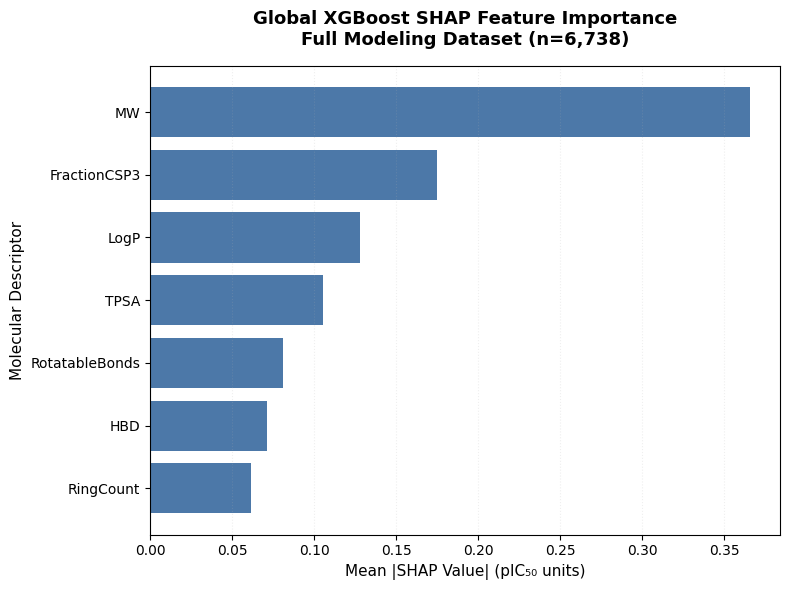

In [8]:
# ============================================================
# 3.1 Global SHAP Feature Importance
# Full Modeling Dataset (n = 6,738)
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Construct the complete descriptor matrix
# ------------------------------------------------------------

X_full = interpretation_df[reduced_descriptors].copy()

print("--- Global SHAP Analysis Dataset ---")
print(f"Compounds:   {len(X_full):,}")
print(f"Descriptors: {X_full.shape[1]}")
print(f"Features:    {X_full.columns.tolist()}")


# ------------------------------------------------------------
# 2. Create SHAP TreeExplainer
# ------------------------------------------------------------

# Uses the finalized XGBoost model reconstructed in Section 2.
# The model is NOT refitted here.

explainer = shap.TreeExplainer(xgb_model)


# ------------------------------------------------------------
# 3. Calculate SHAP values for all 6,738 compounds
# ------------------------------------------------------------

print("\nCalculating SHAP values for the complete dataset...")

shap_values_full = explainer(X_full)

print("SHAP calculation complete.")
print(
    f"SHAP matrix dimensions: "
    f"{shap_values_full.values.shape}"
)


# ------------------------------------------------------------
# 4. Verify SHAP additive consistency
# ------------------------------------------------------------

# For each compound:
# baseline prediction + sum(SHAP contributions)
# should reproduce the XGBoost prediction.

shap_reconstructed_pred = (
    shap_values_full.base_values
    + shap_values_full.values.sum(axis=1)
)

xgb_full_pred = xgb_model.predict(X_full)

max_shap_error = np.max(
    np.abs(
        shap_reconstructed_pred
        - xgb_full_pred
    )
)

print(
    "\nMaximum SHAP reconstruction error: "
    f"{max_shap_error:.8f}"
)


# ------------------------------------------------------------
# 5. Calculate mean absolute SHAP importance
# ------------------------------------------------------------

mean_abs_shap_full = np.abs(
    shap_values_full.values
).mean(axis=0)

shap_importance_full = pd.DataFrame({
    'Descriptor': X_full.columns,
    'MeanAbsSHAP': mean_abs_shap_full
})

shap_importance_full = (
    shap_importance_full
    .sort_values(
        by='MeanAbsSHAP',
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Add relative contribution percentage
# ------------------------------------------------------------

shap_importance_full['RelativeImportance (%)'] = (
    shap_importance_full['MeanAbsSHAP']
    / shap_importance_full['MeanAbsSHAP'].sum()
    * 100
)


# ------------------------------------------------------------
# 7. Display global importance table
# ------------------------------------------------------------

print("\n--- Global XGBoost SHAP Feature Importance ---")

display(
    shap_importance_full.style.format({
        'MeanAbsSHAP': '{:.4f}',
        'RelativeImportance (%)': '{:.1f}'
    })
)


# ------------------------------------------------------------
# 8. Plot global mean |SHAP| importance
# ------------------------------------------------------------

# Reverse order for horizontal bar chart so the
# most important descriptor appears at the top.

plot_df = shap_importance_full.sort_values(
    by='MeanAbsSHAP',
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_df['Descriptor'],
    plot_df['MeanAbsSHAP'],
    color=COLOR_PRIMARY
)

plt.xlabel(
    "Mean |SHAP Value| (pIC₅₀ units)",
    fontsize=11
)

plt.ylabel(
    "Molecular Descriptor",
    fontsize=11
)

plt.title(
    "Global XGBoost SHAP Feature Importance\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    axis='x',
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()

#### Global SHAP Importance Results

Global SHAP analysis identified substantial differences in the contributions of the seven molecular descriptors to XGBoost predictions.

**Molecular Weight (MW)** was the dominant descriptor, with a mean absolute SHAP value of **0.3659 pIC₅₀ units**, accounting for approximately **37.0%** of the total mean absolute SHAP importance. **Fraction Csp³** ranked second (**17.7%**), followed by **LogP** (**12.9%**) and **TPSA** (**10.7%**). Rotatable Bonds, HBD, and Ring Count showed smaller but measurable contributions.

The ranking of **MW > Fraction Csp³ > LogP** is consistent with the leading descriptor ranking observed independently in the Random Forest feature-importance analysis in Notebook 03. This agreement across two different tree-based modeling approaches suggests that these molecular properties represent important sources of predictive information within the selected descriptor space.

Fraction Csp³ is particularly notable because its strong nonlinear model importance contrasts with its relatively weak simple association with experimental pIC₅₀ observed during exploratory analysis. This suggests that its contribution may involve **nonlinear behavior, interactions with other molecular properties, or effects restricted to particular regions of chemical space**.

Mean |SHAP| measures the magnitude of descriptor contributions but does not indicate whether high or low descriptor values increase predicted potency. The direction and distribution of these effects are therefore examined next using the SHAP summary plot.

### 3.2 SHAP Summary Plot

The global mean |SHAP| analysis identifies which molecular descriptors contribute most strongly to XGBoost predictions, but it does not show the **direction of those contributions**. A SHAP summary plot was therefore used to examine how low and high descriptor values influence predicted Nav1.7 inhibitory potency across the complete 6,738-compound dataset.

Each point in the summary plot represents one compound and one molecular descriptor. Its horizontal position represents the descriptor's **SHAP value**, or its contribution to the predicted pIC₅₀:

- **Positive SHAP values** shift the prediction toward higher pIC₅₀ and therefore greater predicted potency.
- **Negative SHAP values** shift the prediction toward lower pIC₅₀ and therefore lower predicted potency.

Point color represents the underlying descriptor value, ranging from relatively **low to high values**. The combination of position and color therefore reveals whether high or low values of a molecular property tend to increase or decrease predicted potency.

Unlike a linear regression coefficient, the SHAP distribution does not assume that a descriptor has a single constant effect across all compounds. A descriptor may produce positive contributions in one region of chemical space and negative contributions in another. Broad, asymmetric, or mixed SHAP distributions can therefore provide initial evidence of **nonlinear behavior, thresholds, or interactions with other molecular properties**.

The summary plot is used primarily to identify these global directional patterns. Detailed relationships between individual descriptor values and their SHAP contributions are examined subsequently using descriptor-specific dependence analyses.

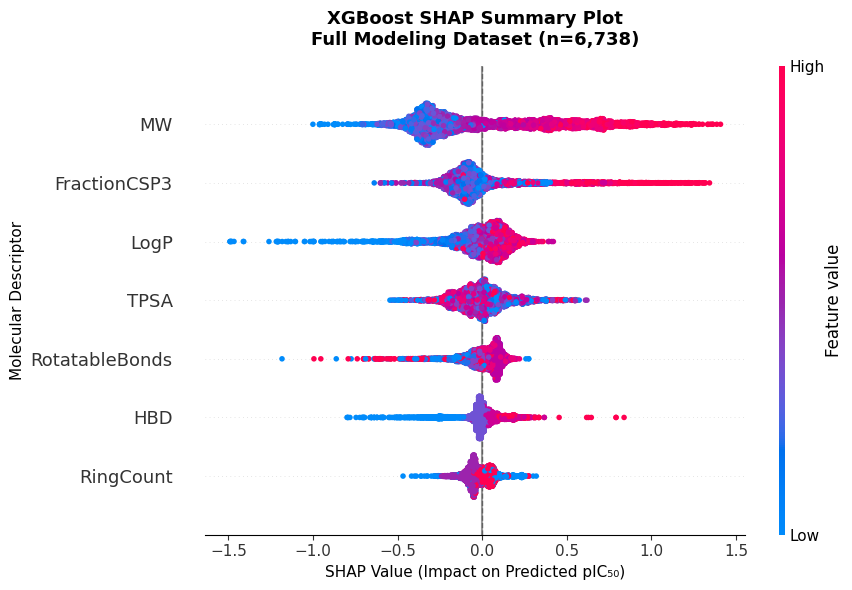

In [9]:
# ============================================================
# 3.2 SHAP Summary Plot
# Full Modeling Dataset (n = 6,738)
# ============================================================

import shap
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Generate SHAP summary / beeswarm plot
# ------------------------------------------------------------

# Uses:
# - shap_values_full calculated in Section 3.1
# - X_full containing all 6,738 compounds
#
# Each point represents one compound.
# Horizontal position = SHAP contribution to predicted pIC50
# Color = underlying descriptor value (low → high)

shap.summary_plot(
    shap_values_full.values,
    X_full,
    feature_names=X_full.columns,
    plot_type="dot",
    max_display=7,
    show=False,
    plot_size=(9, 6)
)


# ------------------------------------------------------------
# 2. Customize plot labels
# ------------------------------------------------------------

plt.title(
    "XGBoost SHAP Summary Plot\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "SHAP Value (Impact on Predicted pIC₅₀)",
    fontsize=11
)

plt.ylabel(
    "Molecular Descriptor",
    fontsize=11
)


# ------------------------------------------------------------
# 3. Add reference line at SHAP = 0
# ------------------------------------------------------------

plt.axvline(
    x=0,
    color=COLOR_TREND,
    linestyle='--',
    linewidth=1,
    alpha=0.8
)


# ------------------------------------------------------------
# 4. Final formatting
# ------------------------------------------------------------

plt.tight_layout()
plt.show()

#### SHAP Summary Results

The SHAP summary plot reveals substantial differences in both the magnitude and direction of descriptor effects across the full modeling dataset.

**Molecular Weight (MW)** shows the strongest directional pattern. Lower MW values are predominantly associated with negative SHAP contributions, whereas higher MW values extend strongly into positive SHAP values. Within the XGBoost model, increasing molecular size is therefore generally associated with increased predicted pIC₅₀, although the distribution indicates that the magnitude of this effect varies among compounds.

**Fraction Csp³** also shows a pronounced but more heterogeneous relationship. Higher Fraction Csp³ values can produce strongly positive SHAP contributions, while substantial overlap remains near zero. This pattern is consistent with the possibility that the influence of three-dimensional carbon character is nonlinear or dependent on other molecular properties.

For **LogP**, very low values are associated with some of the strongest negative SHAP contributions observed in the dataset. Higher LogP values tend to shift contributions toward zero or positive values, although considerable overlap suggests that lipophilicity does not exert a uniform effect across all compounds.

**TPSA** displays a more mixed distribution, with both low and high values occurring on either side of zero. This suggests that the contribution of molecular polarity may depend more strongly on chemical context or interactions with other descriptors.

**Rotatable Bonds** and **HBD** generally make smaller contributions than the leading descriptors, but both show asymmetric patterns. In particular, some compounds with greater flexibility receive strongly negative contributions, while low HBD values are associated with an extended negative SHAP distribution. **Ring Count** exhibits the narrowest overall SHAP distribution, consistent with its lower global importance.

Together, these results show that the nonlinear XGBoost model does not treat the molecular descriptors as having uniform additive effects. Several descriptors exhibit asymmetric, overlapping, or potentially threshold-dependent SHAP distributions, motivating descriptor-specific dependence analysis to determine how their contributions change across their actual numerical ranges.

### 3.3 Held-Out SHAP Robustness Check

The primary SHAP analyses were performed across the complete 6,738-compound dataset to maximize coverage of the chemical descriptor space. However, because 5,390 of these compounds were used to train the XGBoost model, an additional analysis was performed using only the **1,348 held-out test compounds**.

The purpose of this analysis is not to reevaluate predictive performance, which was established in Notebook 03, but to determine whether the principal descriptor-importance patterns identified across the full dataset are also observed among compounds that were excluded from model training.

Mean absolute SHAP values are calculated separately for the held-out test set and compared with the full-dataset results. Particular attention is given to:

- whether the overall descriptor ranking remains similar,
- whether the leading descriptors retain comparable relative importance, and
- whether any descriptor shows a substantial change in importance when analysis is restricted to unseen compounds.

Strong agreement between the two SHAP rankings would indicate that the major interpretation patterns are not confined to the compounds used during model fitting. Conversely, substantial differences could indicate that some learned relationships are more specific to the training chemical space.

This comparison therefore serves as a **robustness check for the global model interpretation** before proceeding to detailed descriptor-specific chemical analysis.

--- Held-Out SHAP Dataset ---
Test compounds: 1,348
Descriptors:    7
Features:       ['MW', 'LogP', 'TPSA', 'HBD', 'RotatableBonds', 'RingCount', 'FractionCSP3']

Calculating SHAP values for held-out test compounds...
SHAP calculation complete.
SHAP matrix dimensions: (1348, 7)

--- Full Dataset vs. Held-Out SHAP Importance ---


,Descriptor,FullMeanAbsSHAP,TestMeanAbsSHAP,FullRelative (%),TestRelative (%),FullRank,TestRank,RankChange
0,MW,0.3659,0.3592,37.0,36.7,1,1,+0
1,FractionCSP3,0.1752,0.1764,17.7,18.0,2,2,+0
2,LogP,0.1279,0.1277,12.9,13.0,3,3,+0
3,TPSA,0.1054,0.0997,10.7,10.2,4,4,+0
4,RotatableBonds,0.0811,0.0804,8.2,8.2,5,5,+0
5,HBD,0.0713,0.0736,7.2,7.5,6,6,+0
6,RingCount,0.0613,0.0622,6.2,6.4,7,7,+0



Spearman rank correlation (Full vs. Test): 1.000


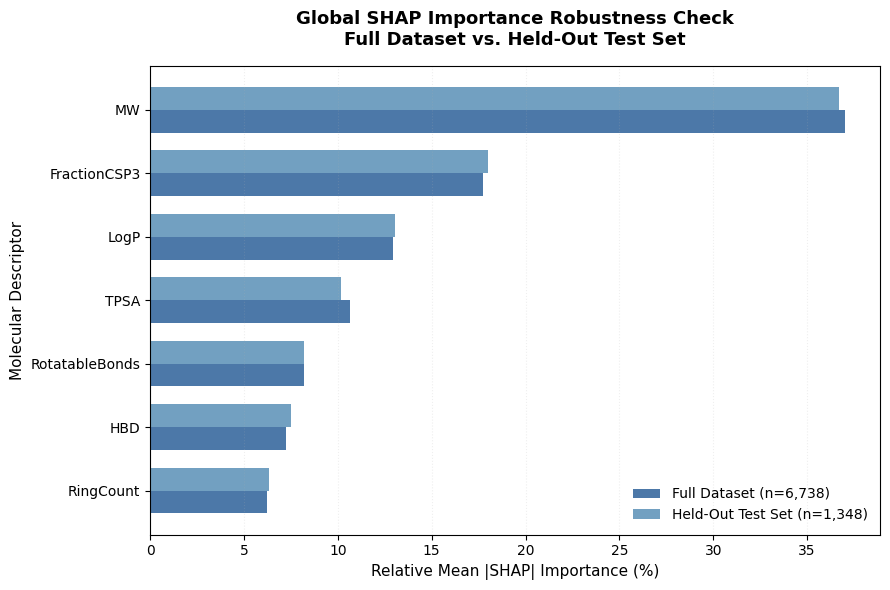

In [10]:
# ============================================================
# 3.3 Held-Out SHAP Robustness Check
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Use the exact held-out test set reconstructed in Section 2
# ------------------------------------------------------------

X_shap_test = X_test_reduced.copy()

print("--- Held-Out SHAP Dataset ---")
print(f"Test compounds: {len(X_shap_test):,}")
print(f"Descriptors:    {X_shap_test.shape[1]}")
print(f"Features:       {X_shap_test.columns.tolist()}")


# ------------------------------------------------------------
# 2. Calculate SHAP values for held-out compounds
# ------------------------------------------------------------

# Reuse the TreeExplainer created in Section 3.1.
# The XGBoost model is NOT refitted.

print("\nCalculating SHAP values for held-out test compounds...")

shap_values_test = explainer(X_shap_test)

print("SHAP calculation complete.")
print(
    f"SHAP matrix dimensions: "
    f"{shap_values_test.values.shape}"
)


# ------------------------------------------------------------
# 3. Calculate held-out mean absolute SHAP importance
# ------------------------------------------------------------

mean_abs_shap_test = np.abs(
    shap_values_test.values
).mean(axis=0)

shap_importance_test = pd.DataFrame({
    'Descriptor': X_shap_test.columns,
    'TestMeanAbsSHAP': mean_abs_shap_test
})


# ------------------------------------------------------------
# 4. Combine with full-dataset SHAP results from Section 3.1
# ------------------------------------------------------------

shap_robustness_df = (
    shap_importance_full[
        ['Descriptor', 'MeanAbsSHAP']
    ]
    .rename(
        columns={
            'MeanAbsSHAP': 'FullMeanAbsSHAP'
        }
    )
    .merge(
        shap_importance_test,
        on='Descriptor'
    )
)


# ------------------------------------------------------------
# 5. Calculate relative importance within each dataset
# ------------------------------------------------------------

shap_robustness_df['FullRelative (%)'] = (
    shap_robustness_df['FullMeanAbsSHAP']
    / shap_robustness_df['FullMeanAbsSHAP'].sum()
    * 100
)

shap_robustness_df['TestRelative (%)'] = (
    shap_robustness_df['TestMeanAbsSHAP']
    / shap_robustness_df['TestMeanAbsSHAP'].sum()
    * 100
)


# ------------------------------------------------------------
# 6. Calculate rank in each dataset
# ------------------------------------------------------------

shap_robustness_df['FullRank'] = (
    shap_robustness_df['FullMeanAbsSHAP']
    .rank(
        ascending=False,
        method='min'
    )
    .astype(int)
)

shap_robustness_df['TestRank'] = (
    shap_robustness_df['TestMeanAbsSHAP']
    .rank(
        ascending=False,
        method='min'
    )
    .astype(int)
)

shap_robustness_df['RankChange'] = (
    shap_robustness_df['TestRank']
    - shap_robustness_df['FullRank']
)


# ------------------------------------------------------------
# 7. Sort by full-dataset importance
# ------------------------------------------------------------

shap_robustness_df = (
    shap_robustness_df
    .sort_values(
        'FullMeanAbsSHAP',
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. Display comparison table
# ------------------------------------------------------------

print("\n--- Full Dataset vs. Held-Out SHAP Importance ---")

display(
    shap_robustness_df.style.format({
        'FullMeanAbsSHAP': '{:.4f}',
        'TestMeanAbsSHAP': '{:.4f}',
        'FullRelative (%)': '{:.1f}',
        'TestRelative (%)': '{:.1f}',
        'RankChange': '{:+d}'
    })
)


# ------------------------------------------------------------
# 9. Calculate rank agreement
# ------------------------------------------------------------

rank_correlation = shap_robustness_df[
    ['FullRank', 'TestRank']
].corr(
    method='spearman'
).iloc[0, 1]

print(
    "\nSpearman rank correlation "
    f"(Full vs. Test): {rank_correlation:.3f}"
)


# ------------------------------------------------------------
# 10. Plot relative SHAP importance comparison
# ------------------------------------------------------------

plot_df = (
    shap_robustness_df
    .sort_values(
        'FullRelative (%)',
        ascending=True
    )
)

y_pos = np.arange(len(plot_df))
bar_height = 0.36

plt.figure(figsize=(9, 6))

plt.barh(
    y_pos - bar_height / 2,
    plot_df['FullRelative (%)'],
    height=bar_height,
    color=COLOR_PRIMARY,
    label='Full Dataset (n=6,738)'
)

plt.barh(
    y_pos + bar_height / 2,
    plot_df['TestRelative (%)'],
    height=bar_height,
    color=COLOR_SECONDARY,
    label='Held-Out Test Set (n=1,348)'
)

plt.yticks(
    y_pos,
    plot_df['Descriptor']
)

plt.xlabel(
    "Relative Mean |SHAP| Importance (%)",
    fontsize=11
)

plt.ylabel(
    "Molecular Descriptor",
    fontsize=11
)

plt.title(
    "Global SHAP Importance Robustness Check\n"
    "Full Dataset vs. Held-Out Test Set",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    axis='x',
    alpha=0.2,
    linestyle=':'
)

plt.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

#### Held-Out SHAP Robustness Results

The global SHAP importance pattern was highly consistent between the complete modeling dataset and the held-out test set.

All seven molecular descriptors retained **exactly the same importance ranking** when the analysis was restricted to the 1,348 compounds excluded from model training. The Spearman rank correlation between the full-dataset and held-out rankings was **1.000**.

The relative importance values were also closely matched. Molecular Weight accounted for **37.0%** of total mean |SHAP| importance across the full dataset and **36.7%** in the held-out set. Fraction Csp³ contributed **17.7%** and **18.0%**, respectively, while LogP contributed **12.9%** and **13.0%**.

The complete ranking remained:

**MW > Fraction Csp³ > LogP > TPSA > Rotatable Bonds > HBD > Ring Count**

This agreement indicates that the principal global descriptor-importance pattern identified across the full dataset is also present when XGBoost is applied exclusively to compounds excluded from model training. The result supports the use of the complete 6,738-compound dataset for subsequent chemical interpretation, where its broader descriptor coverage can provide greater resolution of nonlinear relationships.

This robustness does not establish biological causality or guarantee generalization to chemical space outside the present dataset. Rather, it demonstrates that the major descriptor-importance pattern is not restricted to the training subset.

## 4. Descriptor-Specific SHAP Dependence Analysis

Global SHAP analysis established which molecular descriptors contribute most strongly to XGBoost predictions and revealed broad directional patterns in their effects. However, the summary plot does not directly show **how descriptor contributions change across their numerical ranges**.

Descriptor-specific SHAP dependence analysis was therefore used to examine the relationship between each molecular property and its contribution to predicted Nav1.7 inhibitory potency.

In each dependence plot:

- The **x-axis** represents the observed value of the molecular descriptor.
- The **y-axis** represents its SHAP value, or contribution to the predicted pIC₅₀.
- **Positive SHAP values** indicate contributions toward higher predicted potency.
- **Negative SHAP values** indicate contributions toward lower predicted potency.

Unlike a linear QSAR coefficient, which assumes a constant effect per unit change in a descriptor, SHAP dependence plots allow the learned relationship to vary across descriptor space. These plots can therefore reveal **nonlinear trends, plateaus, transitions, and regions in which the direction or magnitude of a descriptor's contribution changes**.

The analysis is performed across the complete **6,738-compound dataset** to provide dense coverage of the available chemical space. Particular attention is given to **MW, Fraction Csp³, and LogP**, which emerged as the three most influential descriptors in both the XGBoost SHAP analysis and the earlier Random Forest feature-importance analysis.

The remaining descriptors—TPSA, Rotatable Bonds, HBD, and Ring Count—are also examined to determine whether their lower global importance masks chemically meaningful effects within specific descriptor ranges.

Observed SHAP patterns are interpreted as relationships learned by the XGBoost model rather than direct mechanistic effects. Apparent transitions or optimal ranges are therefore treated as **model-derived chemical hypotheses** that may motivate deeper structure-activity investigation rather than as established biological thresholds.

### 4.1 Molecular Weight (MW) Dependence Analysis

Molecular Weight (MW) emerged as the most influential descriptor in the global SHAP analysis, accounting for approximately **37.0% of total mean absolute SHAP importance**. Its SHAP distribution also showed a strong directional pattern, with lower MW values tending to produce negative contributions and higher MW values tending to produce positive contributions to predicted pIC₅₀.

To examine this relationship in greater detail, MW values are plotted directly against their corresponding SHAP contributions across the complete **6,738-compound dataset**.

This analysis is used to determine whether the influence of molecular size is approximately continuous or instead contains **nonlinear regions, transitions, or plateaus**. Of particular interest is whether a characteristic MW range exists where the model's contribution changes from predominantly negative to predominantly positive.

Although such patterns may provide chemically meaningful hypotheses about the relationship between molecular size and Nav1.7 inhibitory potency, MW is a broad molecular property that covaries with other characteristics such as molecular complexity, hydrophobic surface area, and functional-group content. Therefore, any apparent transition or favorable MW range is interpreted as a **model-derived association rather than an independently optimized molecular-weight requirement for Nav1.7 inhibition**.

--- Molecular Weight Distribution ---
Minimum:       227.1 Da
5th percentile:   374.9 Da
25th percentile:  428.1 Da
Median:        472.1 Da
75th percentile:  518.0 Da
95th percentile:  569.1 Da
Maximum:       696.2 Da


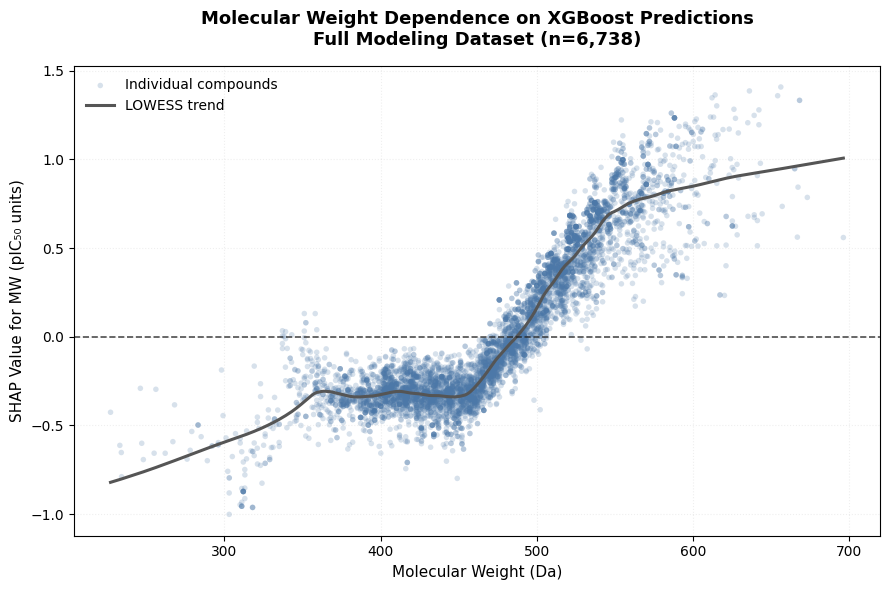

In [11]:
# ============================================================
# 4.1 Molecular Weight (MW) Dependence Analysis
# Full Modeling Dataset (n = 6,738)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess


# ------------------------------------------------------------
# 1. Extract MW values and corresponding SHAP values
# ------------------------------------------------------------

mw_index = X_full.columns.get_loc('MW')

mw_values = X_full['MW'].values

mw_shap = shap_values_full.values[:, mw_index]


# ------------------------------------------------------------
# 2. Create a structured analysis DataFrame
# ------------------------------------------------------------

mw_dependence_df = pd.DataFrame({
    'MW': mw_values,
    'SHAP_MW': mw_shap
})


# ------------------------------------------------------------
# 3. Calculate descriptive MW range
# ------------------------------------------------------------

mw_summary = mw_dependence_df['MW'].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
)

print("--- Molecular Weight Distribution ---")
print(f"Minimum:       {mw_summary['min']:.1f} Da")
print(f"5th percentile:{mw_summary['5%']:8.1f} Da")
print(f"25th percentile:{mw_summary['25%']:7.1f} Da")
print(f"Median:        {mw_summary['50%']:.1f} Da")
print(f"75th percentile:{mw_summary['75%']:7.1f} Da")
print(f"95th percentile:{mw_summary['95%']:7.1f} Da")
print(f"Maximum:       {mw_summary['max']:.1f} Da")


# ------------------------------------------------------------
# 4. Fit LOWESS trend
# ------------------------------------------------------------

# LOWESS provides a locally smoothed representation of the
# model-derived MW-SHAP relationship without assuming linearity.

mw_lowess = lowess(
    endog=mw_dependence_df['SHAP_MW'],
    exog=mw_dependence_df['MW'],
    frac=0.15,
    it=0,
    return_sorted=True
)


# ------------------------------------------------------------
# 5. Plot MW vs. SHAP contribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    mw_dependence_df['MW'],
    mw_dependence_df['SHAP_MW'],
    s=16,
    alpha=0.22,
    color=COLOR_PRIMARY,
    edgecolors='none',
    label='Individual compounds'
)

plt.plot(
    mw_lowess[:, 0],
    mw_lowess[:, 1],
    color=COLOR_TREND,
    linewidth=2.2,
    label='LOWESS trend'
)


# ------------------------------------------------------------
# 6. Add SHAP = 0 reference line
# ------------------------------------------------------------

plt.axhline(
    y=0,
    color=COLOR_ERROR,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8
)


# ------------------------------------------------------------
# 7. Formatting
# ------------------------------------------------------------

plt.xlabel(
    "Molecular Weight (Da)",
    fontsize=11
)

plt.ylabel(
    "SHAP Value for MW (pIC₅₀ units)",
    fontsize=11
)

plt.title(
    "Molecular Weight Dependence on XGBoost Predictions\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    alpha=0.2,
    linestyle=':'
)

plt.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

#### Molecular Weight Dependence Results

The MW dependence plot reveals a strongly **nonlinear relationship** between molecular weight and its contribution to XGBoost-predicted potency.

At lower molecular weights, MW generally contributes negatively to predicted pIC₅₀. The LOWESS trend remains below zero through much of the lower and intermediate MW range and shows a relatively broad negative region around approximately **375–450 Da**.

A pronounced transition occurs at higher molecular weights. Beginning around the upper 400 Da range, the MW contribution rises rapidly, crossing from negative to positive and continuing upward through approximately **500–550 Da**. Beyond this region, the increase becomes more gradual, suggesting a partial plateau in the positive contribution of MW at higher molecular weights.

This nonlinear pattern helps explain why MW emerged as the dominant descriptor in the XGBoost SHAP analysis. The model does not treat each additional unit of molecular weight as producing a constant change in predicted potency. Instead, the influence of MW varies substantially across molecular-size regions.

The vertical spread of SHAP values among compounds with similar MW also indicates that molecular weight does not act independently. Compounds of comparable size can receive substantially different MW contributions, suggesting that the effect learned for MW may depend on the values of other molecular descriptors.

Because MW is correlated with multiple aspects of molecular structure and composition, this relationship should not be interpreted as evidence that simply increasing molecular weight will increase Nav1.7 inhibitory potency. Rather, the model identifies molecular size as an important component of the physicochemical context associated with potency within the chemical space represented by this dataset.